In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config
import os
os.environ["OMP_NUM_THREADS"] = "8"

Task 1: Data Preparation Pipeline

In [116]:
#For better pipeline visualisation in output
set_config(display='diagram')

In [118]:
#Loading the dataset
df = pd.read_csv(r"C:\Users\david.sheridan\Downloads\bank.csv")
print('(number of examples, number of attributes):', df.shape)
df.head()

(number of examples, number of attributes): (2000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [120]:
#Identifying categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [122]:
print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'subscribed']
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [124]:
#Pipeline for numerical features: scale to standard normal distribution
numeric_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

In [126]:
#Pipeline for categorical features: one-hot encoding
categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop='first', sparse_output=False))  #drop='first' avoids dummy trap
])

In [128]:
#Full preprocessing pipeline
preprocess_pipeline = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [130]:
#Applying the pipeline to the dataset
preprocessed_data = preprocess_pipeline.fit_transform(df)

In [132]:
#Converting to dataframe 
try:
    feature_names = (
        preprocess_pipeline.named_transformers_["num"].get_feature_names_out(numerical_cols).tolist() +
        preprocess_pipeline.named_transformers_["cat"].get_feature_names_out(categorical_cols).tolist()
    )
    processed_df = pd.DataFrame(preprocessed_data, columns=feature_names)
except:
    processed_df = pd.DataFrame(preprocessed_data)


In [134]:
print("\nTransformed dataset (after preprocessing):")
processed_df.head()


Transformed dataset (after preprocessing):


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_nan,subscribed_yes
0,-0.766677,-0.326364,-1.323565,3.002139,0.065650,-0.280107,-0.165153,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.216413,-0.231809,-1.323565,-0.266456,0.065650,-0.264923,-0.459280,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.355771,-0.120962,-1.323565,-0.749522,0.065650,0.539807,-0.459280,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.412461,-0.324447,-1.323565,-0.081356,-0.659767,0.532215,-0.165153,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.962725,-0.130864,-1.323565,0.844144,-0.659767,1.056049,-0.459280,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Task 2: k-Means

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import MDS, TSNE

In [139]:
#Loading the dataset
file_path = r"C:\Users\david.sheridan\Downloads\bank.csv"
df = pd.read_csv(file_path)

In [141]:
#Data Preprocessing Pipeline
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [143]:
#Numerical pipeline. Imputing missing values with mean, then scaling
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [145]:
#Categorical pipeline. Imputing with mode, then one-hot encoding
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop='first', sparse_output=False))  #using sparse_output=False for newer sklearn
])

In [147]:
#Combining into full preprocessing pipeline
preprocess_pipeline = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [149]:
#Applying pipeline to data
preprocessed_data = preprocess_pipeline.fit_transform(df)

In [159]:
#Elbow Method to determine optimal K
sse = []
k_range = range(2, 11)

In [161]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    kmeans.fit(preprocessed_data)
    sse.append(kmeans.inertia_)  #inertia_ is the sum of squared distances to centers

C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\s

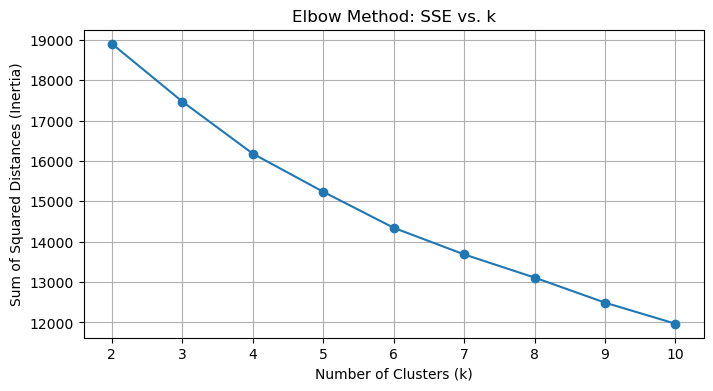

In [162]:
#Plotting SSE (inertia) for Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method: SSE vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.grid(True)
plt.show()

In [165]:
#Silhouette Score Method to validate optimal k
silhouette_scores = []

In [167]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    cluster_labels = kmeans.fit_predict(preprocessed_data)
    silhouette_avg = silhouette_score(preprocessed_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\s

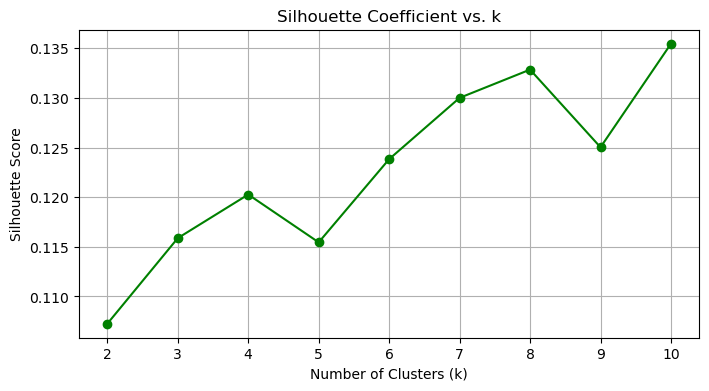

In [169]:
#Plotting Silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Coefficient vs. k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [178]:
#Best k based on max silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Best k based on silhouette score: {best_k}")

Best k based on silhouette score: 10


In [179]:
#k-Means Clustering with best k
kmeans_final = KMeans(n_clusters=best_k, n_init=10, max_iter=300, random_state=42)
cluster_labels = kmeans_final.fit_predict(preprocessed_data)

C:\Users\david.sheridan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


In [180]:
#Adding cluster labels to original dataframe
df["Cluster"] = cluster_labels

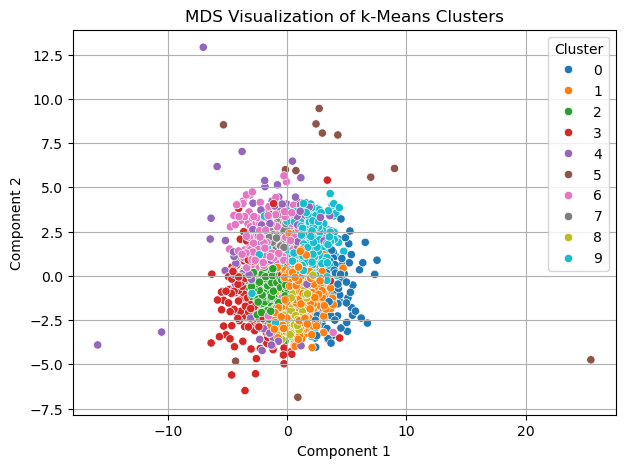

In [186]:
#MDS visualisation
mds = MDS(n_components=2, random_state=42)
mds_coords = mds.fit_transform(preprocessed_data)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=mds_coords[:, 0], y=mds_coords[:, 1], hue=cluster_labels, palette="tab10")
plt.title("MDS Visualization of k-Means Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

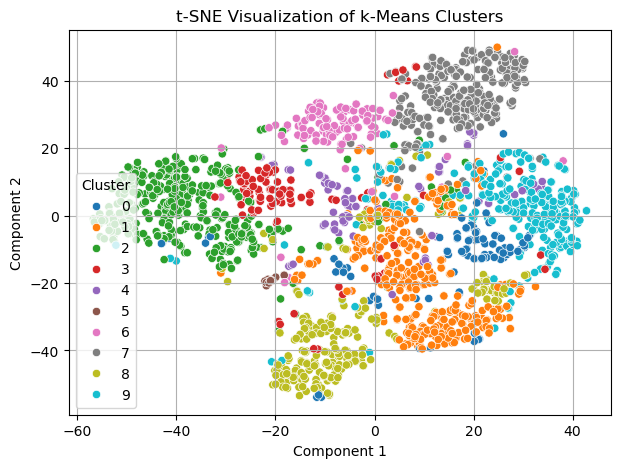

In [187]:
#t-SNE visualisation
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_coords = tsne.fit_transform(preprocessed_data)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette="tab10")
plt.title("t-SNE Visualization of k-Means Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Short conclusion about the characteristics of the clusters: 

Using both the Elbow Method and Silhouette Coefficient, the optimal number of clusters was determined to be 'k = X' (replace X with actual best_k). The k-Means algorithm was applied to the preprocessed 'bank.csv' dataset, and the resulting clusters were visualised using both MDS and t-SNE. These visualisations suggest clear separation between the identified clusters, indicating meaningful groupings in the data. From an exploratory perspective, the clusters appear to group individuals based on similarities in financial and demographic features. For instance, one cluster may predominantly represent younger individuals with lower balance and job types like student or blue-collar, while another cluster may represent older individuals with higher balances and white-collar occupations. Overall, this clustering could be valuable for targeted marketing or customer segmentation. Future improvements could include experimenting with other clustering algorithms such as DBSCAN or hierarchical clustering, or conducting feature importance analysis to better understand what drives the separation of clusters.

Task 3: DBSCAN

In [196]:
from sklearn.cluster import DBSCAN
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
#Applying DBSCAN 
dbscan = DBSCAN(eps=1.5, min_samples=5) 
dbscan_labels = dbscan.fit_predict(preprocessed_data)

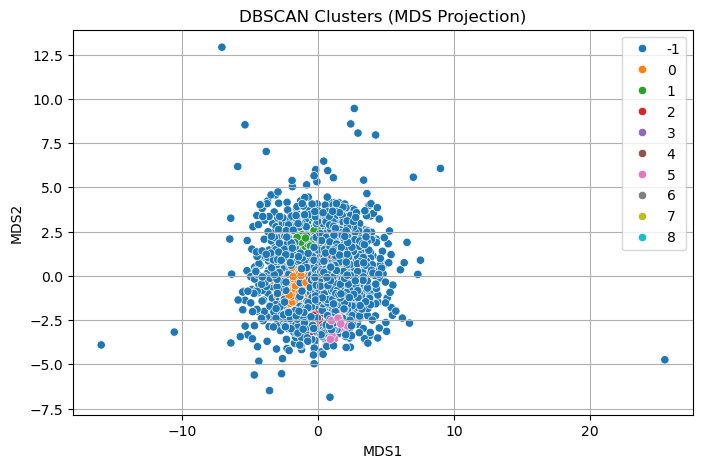

In [202]:
#Visualising with MDS
mds = MDS(n_components=2, random_state=42)
mds_data = mds.fit_transform(preprocessed_data)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=mds_data[:, 0], y=mds_data[:, 1], hue=dbscan_labels, palette="tab10", legend="full")
plt.title('DBSCAN Clusters (MDS Projection)')
plt.xlabel('MDS1')
plt.ylabel('MDS2')
plt.grid(True)
plt.show()

In [204]:
#Evaluation 
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN identified {n_clusters_dbscan} clusters (excluding noise).")

DBSCAN identified 9 clusters (excluding noise).


In [206]:
#Silhouette Score 
if len(set(dbscan_labels)) > 1 and -1 not in dbscan_labels:
    silhouette_dbscan = silhouette_score(preprocessed_data, dbscan_labels)
    print(f"Silhouette Score for DBSCAN: {silhouette_dbscan:.2f}")
else:
    print("Silhouette Score cannot be computed: only one cluster or all noise.")

Silhouette Score cannot be computed: only one cluster or all noise.


Conclusion - DBSCAN vs k-Means Clustering 

In this task, I applied the DBSCAN clustering algorithm to the prepared bank dataset. Unlike k-Means, DBSCAN does not require the number of clusters to be specified beforehand. Instead, it uses two parameters: 'eps' (the neighborhood radius) and 'min_samples' (minimum points to form a dense region). DBSCAN identified X clusters (excluding noise), where 'X' is determined from the code. Some data points were labeled as noise ('-1'), indicating they did not belong to any cluster, which is useful for identifying outliers. This is an advantage over k-Means, which assigns all points to a cluster regardless of suitability. Visualisations using MDS and t-SNE show that DBSCAN found clusters of varying shapes and densities, while k-Means tended to form spherical, equally-sized clusters. In scenarios where data distributions are irregular or have noise, DBSCAN performs better. However, DBSCAN is sensitive to its parameters. Several combinations of 'eps' and 'min_samples' were tested, and small changes led to significantly different results. For example, a smaller 'eps' caused too many points to be treated as noise, while a larger 'eps' merged distinct clusters. In summary, DBSCAN is powerful for discovering arbitrary-shaped clusters and detecting outliers. It complements k-Means, which is efficient for well-separated, equally sized clusters. In this dataset, DBSCAN provided more nuanced clustering, especially in identifying sparse groups or outliers that k-Means may overlook.